In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB


# Load the dataset
df = pd.read_csv('combined_cleaned_cardio_data.csv')

# Explore the first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())
df.info()

   id        age  gender  height  weight  ap_hi  ap_lo        cholesterol  \
0   0  50.357290    male     168    62.0    110     80             normal   
1   1  55.381246  female     156    85.0    140     90  well above normal   
2   2  51.627652  female     165    64.0    130     70  well above normal   
3   3  48.249144    male     169    82.0    150    100             normal   
4   4  47.841205  female     156    56.0    100     60             normal   

     gluc  smoke   alco  active  cardio        bmi age_group  \
0  normal  False  False    True   False  21.967120     50-59   
1  normal  False  False    True    True  34.927679     50-59   
2  normal  False  False   False    True  23.507805     50-59   
3  normal  False  False    True    True  28.710479     40-49   
4  normal  False  False   False   False  23.011177     40-49   

            bp_category  
0              elevated  
1  stage 2 hypertension  
2  stage 1 hypertension  
3  stage 2 hypertension  
4                norma

In [2]:
# Select features and target
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
X = df[features]
y = df['cardio']

# Convert categorical variables (if needed)
X = pd.get_dummies(X, columns=['gender', 'cholesterol', 'gluc'], drop_first=True)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Naive Bayes Classification

In [5]:
model = GaussianNB()

model.fit(X_train_scaled, y_train)

GaussianNB()

In [9]:
y_pred = model.predict(X_test_scaled)

accuray = accuracy_score(y_pred, y_test)
f1 = f1_score(y_pred, y_test, average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.6647142857142857
F1 Score: 0.6737151650980974



True Positives(TP) =  5779

True Negatives(TN) =  3527

False Positives(FP) =  1209

False Negatives(FN) =  3485


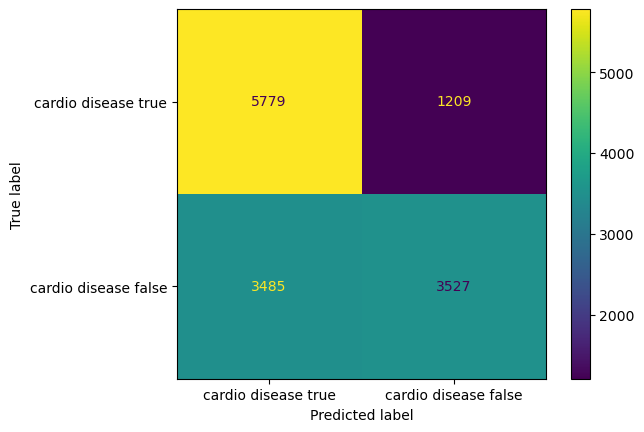

In [14]:
labels = ["cardio disease true", "cardio disease false"]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot();
print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])